# Lesson 04 — Building makemore Part 3: Activations & Gradients, BatchNorm

- **GitHub issue:** [#4](https://github.com/majorgilles/karpathy_ml_course/issues/4)
- **Video:** https://youtu.be/P6sfmUTpUmc
- **Lesson guide:** [../README.md](../README.md)
- **Transcript:** [../transcript.md](../transcript.md)

Use this notebook for exploratory follow-along work. Move reusable code to `../src/`, lightweight checks to `../tests/`, and representative outputs to `../artifacts/`.

## 1. Load names and prepare the diagnostic workspace

This lesson starts from the same character-level name data as the previous MLP lesson so that later activation and gradient observations can be compared on the same prediction problem. `torch` supplies tensor operations, `torch.nn.functional` supplies neural-network helpers, and `matplotlib` is prepared for later plots. `%matplotlib inline` keeps those plots inside the notebook; the imported `float32` symbol is not used by the current cells.

The input is `data/raw/names.txt`, with a fallback path for running the kernel from this notebook's folder. `splitlines()` produces `words`, a Python list containing one complete name per element. The current output confirms the first eight names and a total of 32,033 names. Next, each character needs a stable numeric ID before it can appear in a model input.

In [1]:
import matplotlib.pyplot as plt  # Visualizations used later in the lesson.
import torch  # Tensor operations and model parameters.
import torch.nn.functional as F  # One-hot encoding and other neural-network helpers.

%matplotlib inline

In [2]:
# Load every name; each line in names.txt becomes one training sequence.
from pathlib import Path

candidate_paths = [
    Path("data/raw/names.txt"),  # Kernel launched from the repository root.
    Path("../../../data/raw/names.txt"),  # Kernel launched from this notebook folder.
]
names_path = next(path for path in candidate_paths if path.exists())
words = names_path.read_text(encoding="utf-8").splitlines()

words[:8]  # Inspect a small sample before building numeric examples.

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# Confirm how many complete name sequences are available.
len(words)

32033

## 2. Map characters to model-friendly IDs

The model consumes integer token IDs rather than Python characters. The input is the complete `words` list: `''.join(words)` combines its text, `set(...)` keeps each character once, and `sorted(...)` gives the discovered letters a stable alphabetical order. Discovering the vocabulary from the data also avoids assuming in advance that every dataset contains exactly `a` through `z`.

`stoi` means string-to-index and maps each letter to IDs `1` through `26`; `itos` reverses that mapping for readable output. The boundary token `.` receives ID `0` and will represent both padding before a name and the end after its final letter. The output is therefore a 27-token vocabulary. Next, `BLOCK_SIZE` determines how many preceding token IDs form one input context.

In [4]:
# Collect the 26 lowercase letters once and sort them for reproducible IDs.
chars = sorted(list(set("".join(words))))
# Reserve 0 for the boundary token, so letters begin at index 1.
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
# Invert the mapping: model indices back to printable characters.
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Set the model and optimization hyperparameters

A **hyperparameter** is a setting chosen outside gradient-based training. `BLOCK_SIZE = 3` gives every example three preceding token IDs; `EMBEDDING_SIZE = 10` gives each token a 10-feature vector; and `HIDDEN_SIZE = 200` sets the width of the MLP's hidden layer. `VOCAB_SIZE` is derived from `stoi`, so the current model scores all 27 vocabulary candidates.

Training uses mini-batches of 32 examples for 200,000 parameter-update **steps**. A step processes one randomly sampled mini-batch. It is not an epoch, because an epoch would mean processing every training example once; replacement sampling can repeat some rows and omit others. These values determine the dataset width, parameter shapes, and loop bounds in the next cells.

In [5]:
BLOCK_SIZE = 3  # Number of preceding character IDs in each model input.
EMBEDDING_SIZE = 10  # Learnable features used to represent each token.
HIDDEN_SIZE = 200  # Number of neurons in the MLP hidden layer.
VOCAB_SIZE = len(stoi)  # Twenty-six letters plus the boundary token.
NUMBER_STEPS = 200_000  # Random mini-batch updates, not full-dataset epochs.
MINIBATCH_SIZE = 32  # Training examples contributing to one update.

## 4. Build context-target rows and split complete names

`build_dataset` receives a list of complete names and uses `stoi` plus `BLOCK_SIZE` to produce aligned tensors. For each name, `context` starts as `[0, 0, 0]`. Every loop iteration appends that three-ID context to `X`, appends the one observed next-character ID to `Y`, and then slides the window forward. Iterating over `w + '.'` also creates the final example whose expected target is the end-of-name token.

Each row `X[i]` is one training example's input, while `Y[i]` is its single expected target. The vocabulary contains 27 possible next-token candidates, but this cell does not calculate their probabilities or a loss yet; a later forward pass will assign 27 scores and the probability indexed by `Y[i]` will contribute directly to that example's loss.

On a clean top-to-bottom run, `random.seed(42)` makes the name-level shuffle reproducible. The first 80% of complete names create `Xtr` and `Ytr`, the next 10% create `Xdev` and `Ydev`, and the final 10% create `Xte` and `Yte`. Splitting names before generating rows prevents transitions from one name leaking across splits. The current outputs are `182,625` training rows, `22,655` development rows, and `22,866` test rows, all with three context IDs and one target ID per row. Row percentages differ slightly from 80/10/10 because names have different lengths.

Only `Xtr` and `Ytr` should supply parameter updates. Development data is for comparing choices, and test data stays untouched until final evaluation. The next cells initialize the same baseline MLP as Lesson 03 and preserve its intermediate tensors for activation and gradient inspection.

In [6]:
import random


# Turn one supplied name split into aligned context rows X and next-character targets Y.
def build_dataset(words: list) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []
    for w in words:  # Keep every transition from this split together.
        context = [0] * BLOCK_SIZE  # Start with three boundary-token IDs: "...".

        for ch in w + ".":  # Include the final boundary token as a target.
            ix = stoi[ch]  # Integer ID of the character this context should predict.
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # Drop the oldest ID and append this target ID.

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)  # Inspect this split's context and target tensors.
    return X, Y


random.seed(42)  # Reproduce the same name-level split on each rerun.
random.shuffle(words)  # Shuffle complete names before slicing; do not split individual transitions.
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

# Build training, development, and test tensors from disjoint name groups.
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


## 5. Initialize the MLP with fan-in scaling for `tanh`

   The fixed generator seed makes a fresh top-to-bottom run reproduce the same initial
 values. `C` is the `(27, 10)` embedding table. Three 10-feature embeddings are
 concatenated, so the hidden layer receives `fan_in = 30` input features.

   `W1` uses fan-in scaling with the recommended gain for `tanh`:

   $$
   \operatorname{std}(W_1)
   =
   \frac{5/3}{\sqrt{\mathrm{fan\_in}}}
   =
   \frac{5/3}{\sqrt{30}}
   \approx 0.3043
   $$

   Dividing by the square root of `fan_in` prevents the variance from growing as 30 input
 features are added together. The `5/3` gain compensates for the variance-reducing effect
 of `tanh`. Together, these choices keep the initial hidden pre-activations large enough
 to carry information but less likely to push most `tanh` outputs into saturation near
 `-1` or `1`.

   The hidden bias `b1` is removed because BatchNorm makes a constant shift before normalization redundant. Let `u_ij` be neuron `j`'s weighted input for example `i`. If the same hidden bias `b1_j` were added to every example, it would also appear in that neuron's batch mean and cancel during centering:

   $$
   (u_{ij} + b_{1,j}) - (\mu_{u,j} + b_{1,j}) = u_{ij} - \mu_{u,j}
   $$

   A pre-BatchNorm `b1` therefore cannot control the centered activation. `bnbias`, or beta, remains useful because it shifts each neuron after normalization, where no later centering step removes it. `W2` is multiplied by `0.01` and `b2` is initialized to zero, keeping the initial 27 output logits close to equal. Softmax therefore begins near a uniform candidate distribution, whose expected one-example NLL is:

   $$
   -\log\left(\frac{1}{27}\right)
   =
   \log(27)
   \approx 3.296
   $$

   BatchNorm adds two `(1, 200)` trainable tensors. `bngain` is the per-neuron scale, usually called gamma, and starts at `1`. `bnbias` is the per-neuron shift, usually called beta, and currently also starts at `1`, so the normalized hidden pre-activations initially have mean near `1` rather than `0`. Both tensors are included in `parameters` and learn through backpropagation.

   Removing the 200-element `b1` leaves six trainable tensors with 12,097 scalar parameters:

   $$
   27 \times 10
   +
   30 \times 200
   +
   200 \times 27
   +
   27
   +
   200
   +
   200
   =
   12{,}097
   $$

   All initialization and scaling occurs before `requires_grad` is enabled. The final
 tensors stored in `parameters` are therefore leaf tensors, so `loss.backward()` populates
 each parameter's `.grad` field.

In [7]:
# Use a local fixed seed so this initialization is reproducible.
g = torch.Generator().manual_seed(2147483647)

# Three embedding vectors are concatenated into each hidden-layer input.
fan_in = BLOCK_SIZE * EMBEDDING_SIZE  # 3 × 10 = 30 input features.
tanh_gain = 5 / 3  # Recommended variance-preserving gain for tanh.

# Create and scale the final parameter tensors before enabling autograd.
C = torch.randn(
    VOCAB_SIZE,
    EMBEDDING_SIZE,
    generator=g,
)  # (27, 10): token embeddings.

W1 = (
    torch.randn(
        fan_in,
        HIDDEN_SIZE,
        generator=g,
    )
    * tanh_gain
    / (fan_in**0.5)
)  # (30, 200): fan-in-scaled hidden weights.

W2 = (
    torch.randn(
        HIDDEN_SIZE,
        VOCAB_SIZE,
        generator=g,
    )
    * 0.01
)  # (200, 27): keep initial output logits near zero.

b2 = (
    torch.randn(
        VOCAB_SIZE,
        generator=g,
    )
    * 0
)  # (27,): equal zero output biases.

# BatchNorm affine parameters: one learned scale and shift per hidden neuron.
bngain = torch.ones((1, HIDDEN_SIZE))  # (1, 200): gamma starts as neutral scale 1.
bnbias = torch.ones((1, HIDDEN_SIZE))  # (1, 200): beta currently starts as a +1 shift.

# Non-trainable BatchNorm buffers used as fixed statistics during inference.
bnmean_running = torch.zeros((1, HIDDEN_SIZE))  # (1, 200): running mean starts at 0.
bnstd_running = torch.ones((1, HIDDEN_SIZE))  # (1, 200): running std starts at 1.

# Train four MLP tensors plus BatchNorm gamma and beta; b1 is redundant.
parameters = [C, W1, W2, b2, bngain, bnbias]

# Enable autograd last so every stored parameter remains a leaf tensor.
for p in parameters:
    p.requires_grad = True

In [8]:
# Count all MLP parameters plus the 200 BatchNorm gains and 200 BatchNorm biases.
sum(p.nelement() for p in parameters)

12097

## 6. Train while keeping diagnostic tensors visible

This loop extends the Lesson 03 MLP with manual BatchNorm. `Xb` and `Yb` preserve one sampled mini-batch of paired contexts and targets. `embcat` is the flattened `(B, 30)` MLP input. The first `hpreact` value is the raw `(B, 200)` linear result; the BatchNorm assignment then replaces it with a normalized, scaled, and shifted `(B, 200)` tensor before `tanh` produces `h`.

For each hidden neuron `j`, `mean(0, keepdim=True)` and `std(0, keepdim=True)` summarize that neuron across the `B = 32` training examples. Both statistics have shape `(1, 200)`, so broadcasting applies neuron `j`'s mean and standard deviation to all 32 values in column `j`. Canonical BatchNorm uses these relationships:

$$
\mu_j = \frac{1}{B} \sum_{i=1}^{B} a_{ij}
$$

$$
\sigma_j^2 = \frac{1}{B} \sum_{i=1}^{B} \left(a_{ij} - \mu_j\right)^2
$$

$$
s_j = \sqrt{\sigma_j^2 + \varepsilon}
$$

$$
\widehat{a}_{ij} = \frac{a_{ij} - \mu_j}{s_j}
$$

$$
\widetilde{a}_{ij} = \gamma_j \widehat{a}_{ij} + \beta_j
$$

Here, `i` identifies one training example, `j` identifies one of 200 hidden neurons, `a` is the raw hidden pre-activation, `mu_j` is neuron `j`'s mini-batch mean, and `sigma_j²` is its mini-batch variance. `s_j` is the stabilized standard deviation: epsilon is a small positive constant that prevents division by zero when variance is zero or extremely small. `a-hat` is the normalized pre-activation, gamma is the learned `bngain`, beta is the learned `bnbias`, and `a-tilde` is the BatchNorm output passed to `tanh`.

The current code is a simplified teaching version: `hpreact.std(0, keepdim=True)` uses PyTorch's default sample standard deviation directly, with correction `1`, and does not yet add epsilon. Production-style code instead divides by `sqrt(variance + epsilon)` as shown above.

Training also maintains fixed-size running estimates for later inference. On update step `t`, `bnmeani` and `bnstdi` are the current mini-batch statistics, while `bnmean_running` and `bnstd_running` retain exponential moving averages:

$$
\mu_{\mathrm{run},t} = 0.999\,\mu_{\mathrm{run},t-1} + 0.001\,\mu_t
$$

$$
s_{\mathrm{run},t} = 0.999\,s_{\mathrm{run},t-1} + 0.001\,s_t
$$

The coefficient `0.001` is the contribution from the current mini-batch; `0.999` preserves most of the previous estimate. These running tensors are buffers, not learned parameters: they are excluded from `parameters`, updated manually inside `torch.no_grad()`, and therefore receive no gradients. This notebook tracks running standard deviation directly, whereas PyTorch BatchNorm modules conventionally track running variance.

For each of the `B = 32` training examples, `logits` contains 27 candidate scores and `Yb[i]` identifies the one expected target. Cross-entropy converts those scores internally to probabilities and averages the negative log-probability assigned to the expected targets:

$$
\mathcal{L}_{\mathrm{batch}} = -\frac{1}{B} \sum_{i=1}^{B} \log p_{i, Y_{b,i}}
$$

Here, `B` is the number of sampled training examples, `i` identifies one example, `p` is its 27-candidate probability distribution, and `Yb[i]` is its expected target ID. Only `p[i, Yb[i]]` contributes directly to example `i`'s NLL.

The loop runs 200,000 replacement-sampled update steps: learning rate `0.1` for the first half and `0.01` for the second half. `lossi` records the base-10 logarithm of each sampled mini-batch's average NLL; it is neither a full-training-set loss nor a development loss, and no smoothing is applied here. Rerunning only this loop continues training the existing parameters, so rerun the parameter-initialization cell first when you want a fresh experiment.

`hpreact` and `h` are reassigned on every step. After all 200,000 steps, they contain only the final sampled training mini-batch **after training**, not the initialization-time activations. Karpathy's smooth post-scaling histogram came from reinitializing and stopping after the first mini-batch; a histogram taken after full training may again develop peaks near `-1` and `1` because optimization has changed the weights. The next cell plots the recorded training-loss history.

In [9]:
# Rerun parameter initialization immediately before this cell for a fresh experiment.
# These are the complete training tensors; only sampled Xb/Yb rows enter each update.
print(Xtr.shape)
print(Ytr.shape)

lossi = []  # Base-10 log of the average NLL from each sampled mini-batch.
for step in range(NUMBER_STEPS):
    # Sample B = 32 training-row IDs uniformly with replacement.
    ix = torch.randint(0, Xtr.shape[0], (MINIBATCH_SIZE,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # Paired batch shapes: (B, 3) contexts and (B,) targets.

    # Forward pass: preserve this step's intermediate tensors for activation diagnostics.
    emb = C[Xb]  # (B, 3, 10): one embedding vector per context token.
    embcat = emb.view(-1, EMBEDDING_SIZE * BLOCK_SIZE)  # (B, 30): one row per context.
    # No b1: mini-batch centering would immediately subtract the same bias.
    hpreact = embcat @ W1  # (B, 200): raw linear values before BatchNorm.

    # Compute one current-mini-batch mean and std for each hidden neuron.
    bnmeani = hpreact.mean(0, keepdim=True)  # (1, 200): batch mean at this step.
    bnstdi = hpreact.std(0, keepdim=True)  # (1, 200): batch sample std at this step.
    # Normalize each neuron across dimension 0: the B = 32 training examples.
    # Then apply learned per-neuron scale gamma and shift beta.
    hpreact = (
        bngain * (hpreact - bnmeani) / bnstdi + bnbias
    )  # (B, 200): BatchNorm output passed to tanh.

    # Update inference buffers with an exponential moving average, outside autograd.
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)  # (B, 200): bounded hidden activations after tanh.
    logits = h @ W2 + b2  # (B, 27): one raw score per vocabulary candidate.
    loss = F.cross_entropy(logits, Yb)  # Average NLL for this batch's B expected targets.

    # Backward pass: clear earlier gradients, then differentiate this mini-batch loss.
    for p in parameters:
        p.grad = None
    loss.backward()

    # Use lr = 0.1 for the first 100,000 steps, then decay to 0.01.
    lr = 0.1 if step < NUMBER_STEPS // 2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad  # Instructional direct parameter update.

    # Print occasional unsmoothed mini-batch NLL and retain every log10 loss value.
    if step % 10_000 == 0:
        print(f"{step:7d}/{NUMBER_STEPS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

# After the loop, hpreact and h refer only to the final post-training mini-batch.

torch.Size([182625, 3])
torch.Size([182625])
      0/ 200000: 3.3056
  10000/ 200000: 1.9817
  20000/ 200000: 2.6418
  30000/ 200000: 2.0012
  40000/ 200000: 2.3115
  50000/ 200000: 1.8987
  60000/ 200000: 2.0529
  70000/ 200000: 2.3327
  80000/ 200000: 2.4092
  90000/ 200000: 2.2383
 100000/ 200000: 2.2589
 110000/ 200000: 2.2823
 120000/ 200000: 1.6926
 130000/ 200000: 1.9830
 140000/ 200000: 2.2002
 150000/ 200000: 2.0063
 160000/ 200000: 1.9524
 170000/ 200000: 2.4093
 180000/ 200000: 2.1574
 190000/ 200000: 2.2078


## 7. Plot the unsmoothed mini-batch training history

`lossi` contains one value for every parameter-update step: the base-10 logarithm of that step's average 32-example training NLL. Plotting it against list position therefore uses update step on the horizontal axis and `log10` mini-batch loss on the vertical axis. Lower values mean lower loss, while the visible noise comes from evaluating a different replacement-sampled mini-batch at each step.

This plot uses all 200,000 recorded values without averaging or smoothing. With the current scaled output initialization and BatchNorm, the first printed mini-batch loss is about `3.31`, close to the uniform 27-candidate expectation `log(27) ≈ 3.296`; the remaining values show the noisy overall downward trend. This is not a full-training-set or development-loss curve. The next cell performs those full-split evaluations.

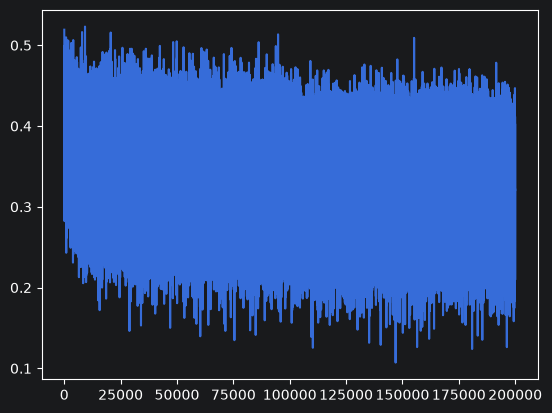

In [10]:
plt.plot(lossi)

## 8. Evaluate with fixed running BatchNorm statistics

`split_loss` receives a split name and selects its complete context tensor `x` and expected-target tensor `y`. Unlike the training loop, it performs no mini-batch sampling, `backward()` call, or parameter update. The `@torch.no_grad()` decorator disables gradient bookkeeping because evaluation only needs the forward values and average NLL.

For a split with `N` examples, the forward shape path is `(N, 3)` token IDs → `(N, 3, 10)` embeddings → `(N, 30)` flattened inputs → `(N, 200)` raw pre-activations → BatchNorm → `(N, 200)` `tanh` activations → `(N, 27)` candidate logits. Cross-entropy selects the candidate indexed by each expected target `y[i]` and averages NLL over all `N` examples.

Inference must not depend on the other examples that happen to be evaluated at the same time. This cell therefore uses the same fixed `(1, 200)` `bnmean_running` and `bnstd_running` buffers for every training or development example instead of recomputing statistics from the selected split. Broadcasting applies those 200 training-time estimates across all `N` rows:

$$
\widetilde{a}_{ij} = \gamma_j \frac{a_{ij} - \mu_{\mathrm{run},j}}{s_{\mathrm{run},j}} + \beta_j
$$

Here, `mu_run,j` and `s_run,j` are the exponential moving estimates collected from training mini-batches for neuron `j`; gamma and beta remain the learned `bngain` and `bnbias`. The buffers are fixed during evaluation, and `@torch.no_grad()` disables both gradient tracking and parameter updates.

The current full-split results are training loss `2.0664` and development loss `2.1113`, a gap of about `0.0449`. The dictionary supports the test split, but this cell deliberately evaluates only `train` and `val`; keep `test` untouched until model choices are final. Next, sampling uses the trained candidate probabilities to generate new names rather than score known targets.

In [11]:
@torch.no_grad()  # Evaluation needs forward values but no gradient graph.
def split_loss(split: str) -> None:
    # Select every aligned context-target pair from the requested split.
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x]  # (N, 3, 10): embeddings for every context in this split.
    embcat = emb.view(emb.shape[0], -1)  # (N, 30): flatten each context.
    hpreact = embcat @ W1  # (N, 200): raw hidden pre-activations.
    # Inference uses fixed statistics accumulated from training mini-batches.
    hpreact = (
        bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    )  # (N, 200): fixed-statistics BatchNorm output.
    h = torch.tanh(hpreact)  # (N, 200): hidden activations after tanh.
    logits = h @ W2 + b2  # (N, 27): candidate scores for every example.
    loss = F.cross_entropy(logits, y)  # Average NLL over the complete split.
    print(split, loss.item())


split_loss("train")
split_loss("val")  # Validation and development refer to the same held-out split here.

train 2.0664174556732178
val 2.1113367080688477


## 9. Generate names one character at a time

Generation starts with one batch-of-one context containing three boundary-token IDs. The sampling path now matches evaluation: it computes raw `(1, 200)` hidden pre-activations, normalizes them with fixed `(1, 200)` running BatchNorm statistics, applies learned gain and bias, and then applies `tanh`. The output layer produces `(1, 27)` logits, and row-wise softmax converts them into probabilities over all 27 next-token candidates. `torch.multinomial` samples one candidate instead of always choosing the largest probability, so repeated generations can differ while the fixed generator seed keeps this saved run reproducible.

After sampling token ID `ix`, the code removes the oldest context ID, appends `ix`, and records it in `out`. That sampled output therefore becomes part of the next input. Generation ends when the model samples boundary-token ID `0`, and `itos` decodes every recorded ID—including the final `.`—into the printed name. There are no expected targets or loss during generation, and gradient tracking is unnecessary.

The loop requests 20 names and scores one context at a time. It must use `bnmean_running` and `bnstd_running`; computing a sample standard deviation from a one-row inference batch would be undefined. Because sampling uses fixed training-time statistics, each prediction is independent of which other examples happen to be evaluated alongside it.


In [12]:
# Use a separate fixed generator so this sequence of sampled names is reproducible.
sample_generator = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():  # Sampling needs probabilities but no gradients or parameter updates.
    for _ in range(20):
        out = []  # Token IDs sampled for this one generated name.
        context = [0] * BLOCK_SIZE  # Batch-of-one context starts as boundary padding: `...`.

        while True:
            # Run the same forward pass for one current context.
            context_tensor = torch.tensor([context], dtype=torch.long)  # (1, 3)
            sample_emb = C[context_tensor]  # (1, 3, 10)
            sample_embcat = sample_emb.view(1, -1)  # (1, 30)
            sample_hpreact = sample_embcat @ W1  # (1, 200): raw hidden values.

            sample_hpreact = (
                bngain * (sample_hpreact - bnmean_running) / bnstd_running + bnbias
            )  # (1, 200): fixed-statistics BatchNorm output.

            # Apply tanh after reproducing the training-time BatchNorm transformation.
            sample_h = torch.tanh(sample_hpreact)  # (1, 200): normalized activations.
            logits = sample_h @ W2 + b2  # (1, 27) candidate scores.
            probs = F.softmax(logits, dim=1)  # (1, 27) probability row summing to one.

            # Sample one next-token ID from the complete candidate distribution.
            ix = torch.multinomial(probs, num_samples=1, generator=sample_generator).item()
            context = context[1:] + [ix]  # Feed the sampled token into the next context.
            out.append(ix)

            if ix == 0:  # Boundary-token ID 0 marks the end of this generated name.
                break

        print("".join(itos[i] for i in out))  # Decode IDs, including the final `.`.

carlah.
amelle.
khyim.
shreety.
sachasie.
mahne.
faresara.
kaqui.
nellara.
chaiiv.
kaleigh.
ham.
joce.
quinn.
salin.
alianni.
wayth.
giearisi.
jaxeenissa.
mel.


# Summary: rebuild the network from reusable layers

## 10. Define small layer objects

The classes below package one tensor transformation together with the tensors and state it owns. Every layer is callable, stores its latest output in `self.out` for later activation or gradient diagnostics, and exposes trainable tensors through `parameters()`. Inputs use one row per training example, so a layer receives a batch-shaped tensor rather than one scalar at a time.

`Linear` performs an affine transformation. For an input batch `X` with shape `(B, fan_in)`, its weight has shape `(fan_in, fan_out)`, its optional bias has shape `(fan_out,)`, and its output has shape `(B, fan_out)`:

$$
Y = XW + b
$$

Here, `B` is the number of examples, `W` is the weight matrix, and `b` is broadcast across all examples. Dividing the initial random weights by `sqrt(fan_in)` controls the variance contributed by summing `fan_in` input features.

`BatchNorm1d` normalizes each feature across dimension `0`, the examples in the current mini-batch. During training it uses the current batch mean and unbiased batch variance, adds `eps` inside the square root for numerical stability, applies learned `gamma` and `beta`, and updates running mean and variance without building a gradient graph. When `training` is `False`, it uses those fixed running statistics instead of statistics from the inference batch. Its `parameters()` method returns only `gamma` and `beta`; running statistics are non-trainable buffers.

`Tanh` applies `torch.tanh` element by element without owning trainable tensors. It therefore returns an empty parameter list. Together, these common interfaces allow later code to call layers sequentially and collect parameters without special cases for each layer type.


In [13]:
# Use a separate generator so the rebuilt network is reproducible.
g = torch.Generator().manual_seed(2147483647 + 10)


class Linear:
    """Affine layer: map `(B, fan_in)` inputs to `(B, fan_out)` outputs."""

    def __init__(self, fan_in: int, fan_out: int, bias: bool | None = True) -> None:
        super().__init__()
        # Fan-in scaling keeps output variance from growing with input width.
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight  # (B, fan_out): weighted sums for every example.
        if self.bias is not None:
            self.out += self.bias  # Broadcast one feature bias across the batch.
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        # Return only tensors that gradient descent should update.
        return [self.weight] + ([self.bias] if self.bias is not None else [])


class BatchNorm1d:
    """Normalize each feature across a batch, then learn scale and shift."""

    def __init__(self, dim: int, eps=1e-5, momentum=0.1) -> None:
        super().__init__()
        self.eps = eps  # Stabilize division when variance is tiny.
        self.momentum = momentum  # Current-batch contribution to running buffers.
        self.training = True  # Choose batch statistics or running statistics.

        # Trainable affine parameters: one scale and shift per feature.
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Non-trainable buffers used to normalize future inference examples.
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            # One mean and unbiased variance per feature across batch dimension 0.
            x_mean = x.mean(0, keepdim=True)
            x_var = x.var(0, keepdim=True, unbiased=True)
        else:
            # Inference uses fixed training estimates, not its current batch.
            x_mean = self.running_mean
            x_var = self.running_var

        # Normalize safely, then restore learned per-feature scale and shift.
        x_hat = (x - x_mean) / torch.sqrt(x_var + self.eps)
        self.out = self.gamma * x_hat + self.beta

        if self.training:
            # Buffers follow exponential moving averages but receive no gradients.
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * x_var
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return [self.gamma, self.beta]


class Tanh:
    """Elementwise tanh activation with no trainable parameters."""

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)  # Preserve shape and bound values to (-1, 1).
        return self.out

    def parameters(self) -> list[torch.Tensor]:
        return []

## 11. Assemble and initialize the deeper BatchNorm MLP

The rebuilt model keeps 10 embedding features per character and uses five hidden layers of 100 neurons. Each three-character context becomes 30 concatenated embedding features. Every hidden block now follows `Linear → BatchNorm1d → Tanh`, and the final `Linear` layer produces 27 vocabulary logits. The BatchNorm layers normalize their 100 incoming features, learn 100 gamma scales and 100 beta shifts, and retain running statistics for inference.

The current `Linear` calls leave their optional biases enabled. A bias immediately before BatchNorm is mathematically redundant because batch centering subtracts it back out, but the current code still includes those tensors in `parameters`. This section documents that saved implementation without removing them.

The embedding table `C` is trained alongside every tensor returned by each layer's `parameters()` method. The current model contains 47,497 trainable scalar values:

$$
27 \times 10
+
(30 \times 100 + 100)
+
4(100 \times 100 + 100)
+
5(100 + 100)
+
(100 \times 27 + 27)
=
47{,}497
$$

The five `(100 + 100)` terms are BatchNorm gamma and beta. Running means and variances are buffers and therefore do not contribute to the trainable parameter count.

The final output weights are multiplied by `0.1` so the initial 27 logits are less extreme. Every hidden `Linear` weight starts with `1 / sqrt(fan_in)` scaling and is then multiplied by the `5/3` gain used for `tanh`. BatchNorm will subsequently control hidden activation scale, but this initialization is retained from the preceding experiment. Scaling occurs before `requires_grad` is enabled, keeping the stored tensors as leaves.

The displayed `46,497` output and downstream plots were produced before the five BatchNorm layers were inserted. Restart the kernel and rerun from the layer-definition cell onward before interpreting parameter counts, losses, diagnostic plots, or generated names for this architecture.


In [14]:
EMBEDDING_SIZE = 10  # Number of learned features in each character embedding.
HIDDEN_SIZE = 100  # Number of neurons in each of the five hidden layers.

# Reinitialize a `(27, 10)` embedding table for this deeper model.
C = torch.randn((VOCAB_SIZE, EMBEDDING_SIZE), generator=g)

# Five hidden Linear/BatchNorm/Tanh blocks feed one 27-logit output layer.
# Linear biases remain enabled even though the following BatchNorm makes them redundant.
layers = [
    Linear(EMBEDDING_SIZE * BLOCK_SIZE, HIDDEN_SIZE),  # (B, 30) -> (B, 100)
    BatchNorm1d(HIDDEN_SIZE),
    Tanh(),
    Linear(HIDDEN_SIZE, HIDDEN_SIZE),  # (B, 100) -> (B, 100)
    BatchNorm1d(HIDDEN_SIZE),
    Tanh(),
    Linear(HIDDEN_SIZE, HIDDEN_SIZE),
    BatchNorm1d(HIDDEN_SIZE),
    Tanh(),
    Linear(HIDDEN_SIZE, HIDDEN_SIZE),
    BatchNorm1d(HIDDEN_SIZE),
    Tanh(),
    Linear(HIDDEN_SIZE, HIDDEN_SIZE),
    BatchNorm1d(HIDDEN_SIZE),
    Tanh(),
    Linear(HIDDEN_SIZE, VOCAB_SIZE),  # (B, 100) -> (B, 27) logits.
]

with torch.no_grad():
    # Keep initial output logits less extreme so softmax starts less confident.
    layers[-1].weight *= 0.1

    # Apply the tanh gain to each hidden Linear layer, not the output layer.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

# Train the embedding table with every parameter owned by every layer.
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # Current total: 47,497 scalar values.

# Enable autograd last so all stored parameters remain leaf tensors.
for p in parameters:
    p.requires_grad = True

47497


## 12. Train the deeper model while recording diagnostics

This loop performs all `NUMBER_STEPS = 200_000` replacement-sampled parameter updates. Each update deliberately uses only one mini-batch of `B = 32` training examples; it does not score the complete training or development split. The loop prints at steps `0`, `10_000`, through `190_000`, while `lossi` and `ud` each receive 200,000 entries.

The forward pass maps `(32, 3)` context IDs to `(32, 3, 10)` embeddings, flattens each context to `(32, 30)`, and sends the batch through all five `Linear → BatchNorm1d → Tanh` hidden blocks and the output `Linear` layer. The final `(32, 27)` tensor contains 27 candidate scores per training example. `Yb[i]` identifies example `i`'s one expected target, and cross-entropy averages the negative log-probability assigned to the 32 expected targets.

Calling `retain_grad()` on every `layer.out` preserves gradients for these non-leaf intermediate tensors. This adds diagnostic overhead but allows the following cells to inspect the final mini-batch's layer-output gradients after training. Parameter gradients are retained automatically. Remove `retain_grad()` when those plots are no longer needed; it is unrelated to the `retain_graph` option of `backward()`.

`lossi` stores one base-10 mini-batch loss per update:

$$
\mathrm{lossi}_i = \log_{10}(\mathcal{L}_i)
$$

Here, `L_i` is update step `i`'s average 32-example training NLL, not a full-split loss.

For every parameter tensor `p`, `ud` stores a base-10 update-to-data ratio:

$$
\mathrm{ud}_{i,p}
=
\log_{10}\left(
\frac{\operatorname{std}(\mathrm{lr}_i \, \nabla_p \mathcal{L}_i)}
{\operatorname{std}(p)}
\right)
$$

The numerator measures the typical gradient-update size and the denominator measures the parameter scale after this loop's in-place update. Each outer row is one update step; each value in that row corresponds to one tensor in `parameters`.


In [15]:
lossi = []  # One log10 average mini-batch NLL per completed update step.
ud = []  # One row of per-parameter log10 update-to-data ratios per step.

for i in range(NUMBER_STEPS):
    # Sample B = 32 aligned training examples uniformly with replacement.
    ix = torch.randint(0, Xtr.shape[0], (MINIBATCH_SIZE,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # (B, 3) contexts and (B,) expected target IDs.

    # Forward pass through the embedding table and every reusable layer.
    emb = C[Xb]  # (B, 3, 10): one embedding per context character.
    x = emb.view(emb.shape[0], -1)  # (B, 30): concatenate each context's embeddings.
    for layer in layers:
        x = layer(x)  # Final shape: (B, 27) candidate next-character logits.
    loss = F.cross_entropy(x, Yb)  # Average NLL for this sampled training mini-batch.

    # Preserve non-leaf layer-output gradients for the immediate diagnostic plots.
    for layer in layers:
        layer.out.retain_grad()  # AFTER_DEBUG: remove when output gradients are not inspected.

    # Clear gradients from the previous step, then differentiate this step's loss.
    for p in parameters:
        p.grad = None
    loss.backward()

    # Apply the same two-stage learning-rate schedule to every trainable tensor.
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad  # Instructional in-place gradient-descent update.

    # Print occasional unsmoothed mini-batch loss and retain one loss value per step.
    if i % 10_000 == 0:
        print(f"{i:7d}/{NUMBER_STEPS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())  # This is not a full-split loss.

    # Compare each gradient update's std with that parameter's post-update std.
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/ 200000: 3.2958
  10000/ 200000: 1.8951
  20000/ 200000: 2.2393
  30000/ 200000: 1.9686
  40000/ 200000: 1.7739
  50000/ 200000: 1.8676
  60000/ 200000: 2.1924
  70000/ 200000: 1.9099
  80000/ 200000: 1.8483
  90000/ 200000: 2.2063
 100000/ 200000: 2.0705
 110000/ 200000: 2.1581
 120000/ 200000: 2.1146
 130000/ 200000: 1.9537
 140000/ 200000: 2.2467
 150000/ 200000: 1.9549
 160000/ 200000: 1.8650
 170000/ 200000: 2.0028
 180000/ 200000: 2.2435
 190000/ 200000: 2.1693


## 13. Inspect hidden activation distributions

This diagnostic reads the most recently stored `out` tensor from each hidden `Tanh` layer and deliberately excludes the final output `Linear` layer. After full training, every selected tensor belongs to the final sampled mini-batch and has shape `(32, 100)`: 32 sampled training examples by 100 hidden neurons. Flattening is implicit in the summary statistics and histogram, so each layer contributes 3,200 activation values.

For each hidden layer, the printed mean shows whether activations are centered, the standard deviation shows their spread, and the saturation percentage measures the fraction close to the flat ends of `tanh`:

$$
\mathrm{saturation}
=
100 \, \frac{1}{BH}
\sum_{i=1}^{B}
\sum_{j=1}^{H}
\mathbf{1}\left[|h_{ij}| > 0.97\right]
$$

Here, `B = 32` is the number of sampled examples, `H = 100` is the hidden width, and the indicator contributes `1` when an activation magnitude exceeds `0.97`. Heavy saturation matters because the derivative of `tanh` is small near `-1` and `1`, which can weaken gradients flowing into earlier layers. `torch.histogram(..., density=True)` estimates a density rather than raw counts, and the detached histogram coordinates are used only for plotting.

The currently displayed layer indices and histograms predate insertion of BatchNorm layers. Rerun model initialization and training before using them to diagnose the current architecture.


layer 2 (      Tanh): mean +0.02, std 0.69, saturated: 13.88%
layer 5 (      Tanh): mean -0.01, std 0.73, saturated: 16.66%
layer 8 (      Tanh): mean -0.00, std 0.75, saturated: 17.69%
layer 11 (      Tanh): mean -0.02, std 0.77, saturated: 19.38%
layer 14 (      Tanh): mean -0.01, std 0.59, saturated: 6.22%


Text(0.5, 1.0, 'activation distribution')

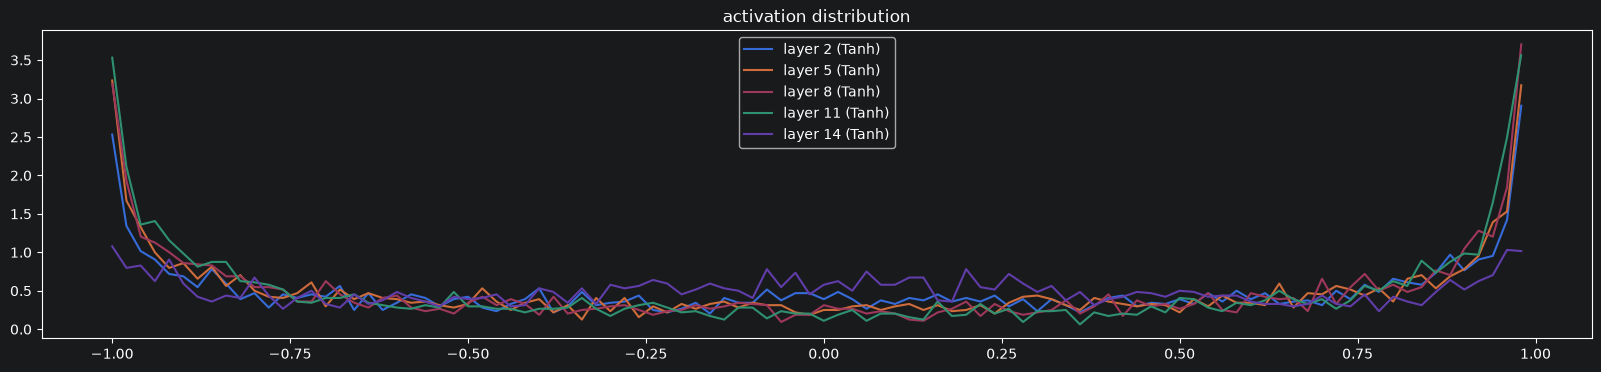

In [16]:
# Overlay density histograms for every hidden tanh layer's latest activations.
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):  # Exclude the final output Linear layer.
    if isinstance(layer, Tanh):
        t = layer.out  # (B, 100): latest post-tanh hidden activations.
        saturation = (t.abs() > 0.97).float().mean() * 100
        print(
            f"layer {i} ({layer.__class__.__name__:>10s}): "
            f"mean {t.mean().item():+.2f}, std {t.std().item():.2f}, "
            f"saturated: {saturation.item():.2f}%"
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends)
plt.title("activation distribution")

## 14. Inspect gradients flowing through hidden activations

This plot examines `layer.out.grad` for each hidden `Tanh` layer after the final retained backward pass of training. These are gradients of the mini-batch average loss with respect to the post-`tanh` activations, not gradients of the layer's weight matrix. They exist because the training loop called `retain_grad()` before `loss.backward()`.

Each gradient tensor again has shape `(32, 100)`. Means near zero show that positive and negative gradient directions are broadly balanced; standard deviations show the typical gradient scale. Similar spreads across depth suggest that gradients are propagating without exploding or collapsing abruptly. The histogram overlays make it easier to compare the complete distributions than a single mean or standard deviation alone.


layer 2 (      Tanh): mean +0.000000, std 4.495673e-03
layer 5 (      Tanh): mean +0.000000, std 4.402526e-03
layer 8 (      Tanh): mean +0.000000, std 4.272083e-03
layer 11 (      Tanh): mean +0.000000, std 4.140038e-03
layer 14 (      Tanh): mean -0.000108, std 6.152465e-03


Text(0.5, 1.0, 'gradient distribution')

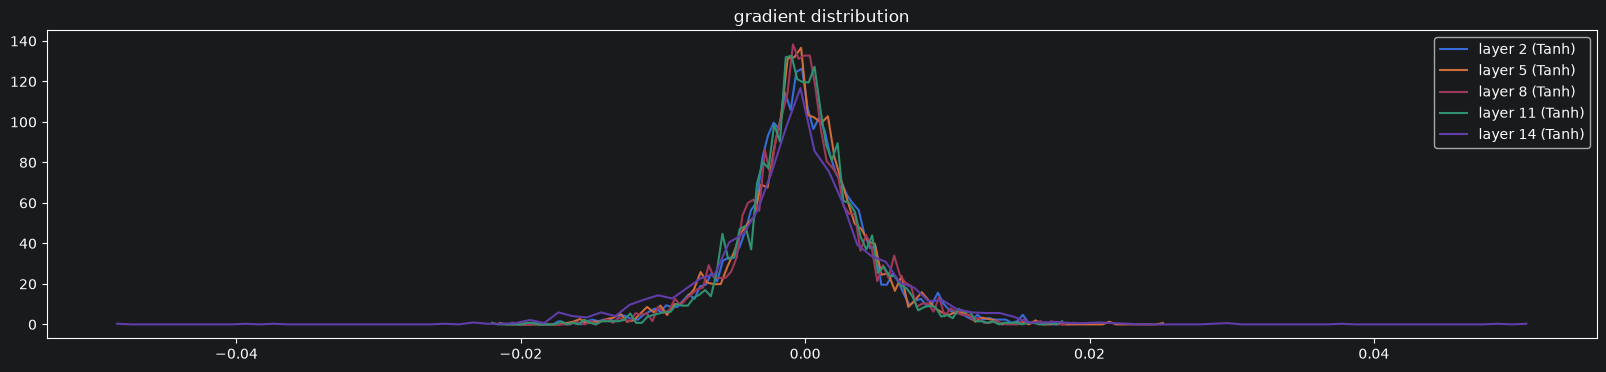

In [17]:
# Overlay gradients with respect to every hidden tanh layer's latest output.
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):  # Exclude the final output Linear layer.
    if isinstance(layer, Tanh):
        t = layer.out.grad  # (B, 100): d(loss) / d(post-tanh activation).
        print(
            f"layer {i} ({layer.__class__.__name__:>10s}): "
            f"mean {t.mean().item():+f}, std {t.std().item():e}"
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends)
plt.title("gradient distribution")

## 15. Compare weight-gradient distributions

This diagnostic iterates over all tensors in `parameters` but plots only matrices with `p.ndim == 2`. That includes the `(27, 10)` embedding table and every `Linear` weight matrix while excluding one-dimensional bias vectors. For each matrix, `p.grad` is the gradient of the current 32-example average NLL with respect to that parameter.

The printed gradient-to-data ratio is:

$$
\frac{\operatorname{std}(\nabla_p \mathcal{L})}
{\operatorname{std}(p)}
$$

This ratio compares gradient scale with parameter scale but does not yet include the learning rate. A larger value means the raw gradient is large relative to the existing weights. The overlaid density histograms show whether different matrices receive gradients with roughly comparable spreads or whether one layer is an outlier.


weight   (27, 10) | mean +0.000000 | std 1.644475e-02 | grad:data ratio 1.477912e-02
weight  (30, 100) | mean -0.000024 | std 9.483896e-03 | grad:data ratio 2.321918e-02
weight (100, 100) | mean -0.000056 | std 6.374881e-03 | grad:data ratio 2.571105e-02
weight (100, 100) | mean +0.000065 | std 6.754463e-03 | grad:data ratio 2.744215e-02
weight (100, 100) | mean +0.000023 | std 6.341811e-03 | grad:data ratio 2.617354e-02
weight (100, 100) | mean -0.000059 | std 6.038196e-03 | grad:data ratio 2.559735e-02
weight  (100, 27) | mean +0.000000 | std 1.761775e-02 | grad:data ratio 7.845161e-02


Text(0.5, 1.0, 'weight-gradient distribution')

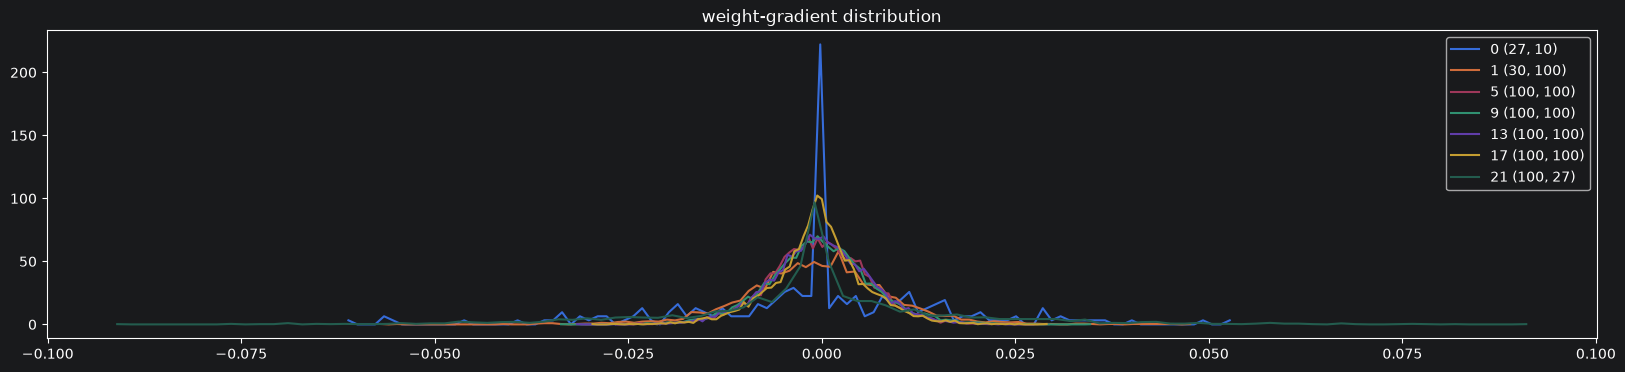

In [18]:
# Overlay gradient distributions for the embedding and Linear weight matrices.
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:  # Exclude one-dimensional bias vectors.
        grad_data_ratio = t.std() / p.std()
        print(
            f"weight {str(tuple(p.shape)):>10s} | mean {t.mean().item():+f} | "
            f"std {t.std().item():e} | grad:data ratio {grad_data_ratio.item():e}"
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"{i} {tuple(p.shape)}")
plt.legend(legends)
plt.title("weight-gradient distribution")

## 16. Plot update-to-data ratios across training steps

For every matrix parameter, this plot reads the corresponding column from `ud`. The horizontal axis is update step and the vertical axis is the base-10 logarithm of the update-to-data ratio recorded by the training loop. A value of `-3` means the typical update magnitude is about one-thousandth of the parameter magnitude:

$$
10^{-3} = 0.001
$$

The black horizontal reference line marks this rough diagnostic target. It is a heuristic rather than a loss or correctness threshold. A fresh full run creates a 200,000-point trajectory for every parameter matrix. Bias vectors are deliberately excluded by the `p.ndim == 2` condition.


Text(0.5, 1.0, 'update-to-data ratio')

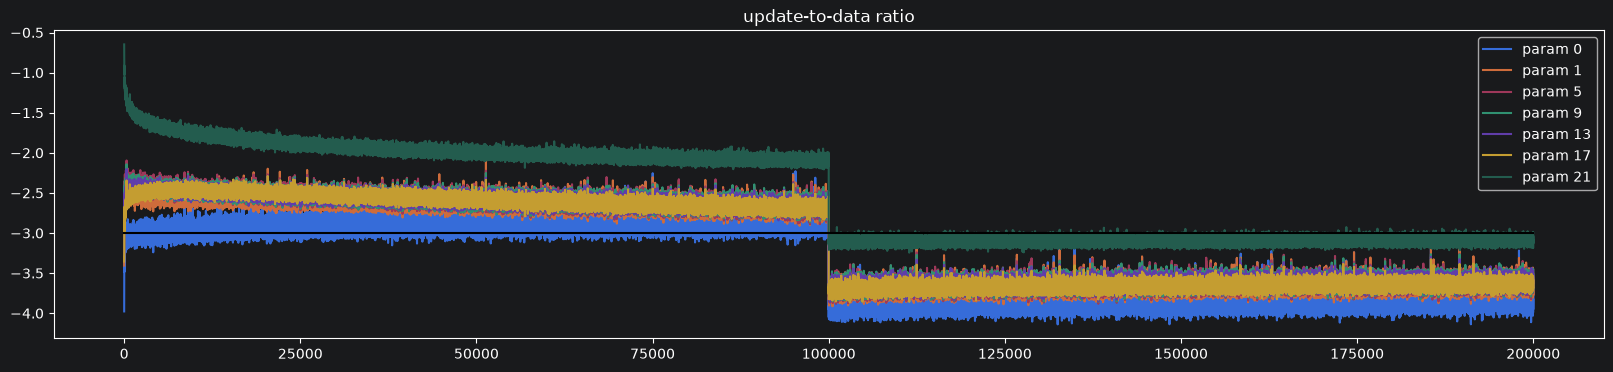

In [19]:
# Plot each matrix parameter's log10 update-to-data ratio over completed steps.
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:  # Exclude one-dimensional bias vectors.
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f"param {i}")

# A log10 ratio of -3 corresponds to an update about 0.001 times parameter scale.
plt.plot([0, len(ud)], [-3, -3], "k")
plt.legend(legends)
plt.title("update-to-data ratio")

## 17. Evaluate the deeper model on complete splits

The new `split_loss` forwards every context-target pair from the requested split through the embedding table and reusable `layers`, then reports one average cross-entropy loss. It performs no mini-batch sampling, backward pass, or parameter update. The `@torch.no_grad()` decorator avoids building a graph because evaluation needs only logits and loss values.

Before evaluation, every layer receives `training = False`. This has no numerical effect on the current `Linear` and `Tanh` layers, but it makes any future `BatchNorm1d` layer use fixed running statistics rather than statistics from the evaluated split. The current cell evaluates the complete training and development datasets while leaving the test split untouched. Its displayed losses predate insertion of BatchNorm layers, so rerun initialization, training, and evaluation before comparing the current architecture's full-split results.


In [20]:
@torch.no_grad()  # Full-split evaluation needs no gradient graph.
def split_loss(split: str) -> None:
    # Select every aligned context-target pair from the requested split.
    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]

    emb = C[x]  # (N, 3, 10): embeddings for every context in this split.
    x = emb.view(emb.shape[0], -1)  # (N, 30): concatenate each context's embeddings.
    for layer in layers:
        x = layer(x)  # Final shape: (N, 27) vocabulary-candidate logits.
    loss = F.cross_entropy(x, y)  # Average NLL over all N examples in this split.
    print(split, loss.item())


# Put all layers in inference mode; BatchNorm would then use running statistics.
for layer in layers:
    layer.training = False

split_loss("train")
split_loss("val")  # Development and validation name the same held-out split here.

train 2.015134572982788
val 2.083923816680908


## 18. Sample names from the deeper model

Generation starts from the boundary-padded context `...` and repeatedly forwards one `(1, 3)` context through the embedding table and evaluation-mode layers. The final layer returns `(1, 27)` logits, softmax produces one probability distribution over all vocabulary candidates, and `torch.multinomial` samples one next-token ID. That sampled token enters the next context, so generation is autoregressive.

Sampling stops when token ID `0`, the boundary token `.`, is selected. There are no expected targets, loss, backward pass, or parameter updates. The separate fixed generator makes the saved sequence reproducible. The layers remain in inference mode from the preceding evaluation cell; if `BatchNorm1d` layers are inserted later, run that mode-setting step before sampling so one-example generation uses running statistics.

The current cell does not disable gradient tracking, even though sampling does not need a gradient graph. This does not change the generated probabilities, but a later cleanup can wrap generation in `torch.no_grad()` to avoid retaining unnecessary autograd state.

The displayed names also predate insertion and training of the BatchNorm layers. They are saved historical output, not samples from the current unexecuted architecture.


In [21]:
# Use a separate fixed generator so the sampled sequence is reproducible.
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []  # Token IDs sampled for this generated name.
    context = [0] * BLOCK_SIZE  # Start from boundary padding: `...`.

    while True:
        # Forward one current context through the evaluation-mode network.
        context_tensor = torch.tensor([context], dtype=torch.long)  # (1, 3)
        emb = C[context_tensor]  # (1, 3, 10): one embedding per context token.
        x = emb.view(emb.shape[0], -1)  # (1, 30): concatenate context embeddings.
        for layer in layers:
            x = layer(x)
        logits = x  # (1, 27): one score per vocabulary candidate.
        probs = F.softmax(logits, dim=1)  # (1, 27): probability row summing to one.

        # Sample one candidate, shift the context, and feed the result back in.
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:  # Boundary-token ID 0 marks the end of this generated name.
            break

    print("".join(itos[i] for i in out))  # Decode IDs, including the final `.`.

carmah.
amorie.
khyimish.
taty.
skanden.
jazzien.
deliah.
jareen.
nellara.
chaiir.
kaleigh.
ham.
jois.
quint.
suline.
liven.
corterri.
jarynn.
jace.
pinsley.
